# Cascade-Mind × GRPO — SRE Blast-Radius Agent (Llama-3-8B Base)

**Train a Meta-Llama-3-8B agent to trace microservice blast radii using Group Relative Policy Optimization (GRPO) via HF TRL.**

Same environment, same reward design as the 3B version — using the Llama 3 8B base model.

| Setting | Value |
|---------|-------|
| Model | `meta-llama/Meta-Llama-3-8B` (4-bit NF4) |
| Environment | Cascade-Mind in-process (no HTTP) |
| Reward | Terminal F-beta (β=2) + budget efficiency + repetition penalty |
| Generation | Standard `transformers.generate()` (no vLLM) |
| Seeds | 12 (seeds 0-11, difficulty = seed % 3) |
| Generations/step | 2 → 24 total rollouts |


## 1 — Install Dependencies

Clones the Cascade-Mind repo so the environment runs in-process (no network calls during rollouts).

In [1]:
%%capture
import subprocess, sys

# 1. Clone Cascade-Mind env (for in-process import)
result = subprocess.run(
    ["git", "clone", "--depth=1",
     "https://huggingface.co/spaces/Rajkamal2819/cascade-mind",
     "/content/cascade-mind"],
    capture_output=True, text=True
)
if result.returncode != 0 and "already exists" not in result.stderr:
    print("Clone failed:", result.stderr)

# 2. Add to Python path (import directly, avoids full package install overhead)
if "/content/cascade-mind" not in sys.path:
    sys.path.insert(0, "/content/cascade-mind")

# 3. Install env deps + TRL + training stack
!pip install -q \
    networkx>=3.0 \
    "pydantic>=2.0" \
    "jinja2==3.1.4" \
    huggingface_hub>=0.24.0 \
    git+https://github.com/huggingface/trl.git \
    "transformers>=4.45.0" \
    "accelerate>=0.34.0" \
    "bitsandbytes>=0.43.0" \
    datasets \
    trackio \
    peft

print("✅ Dependencies installed")

## 2 — Authenticate with Hugging Face

You need:
1. A HF token with **read** access — [get yours here](https://huggingface.co/settings/tokens)
2. The [Meta Llama 3 license accepted](https://huggingface.co/meta-llama/Meta-Llama-3-8B) on your account

In [2]:
import os
from huggingface_hub import login, whoami

# Set your HuggingFace token (must have read access to gated repos)
HF_TOKEN = os.environ.get("HF_TOKEN", "YOUR_HF_TOKEN_HERE")

login(token=HF_TOKEN, add_to_git_credential=False)

try:
    me = whoami(token=HF_TOKEN)
    print(f"✅ Logged in as: {me['name']}")
except Exception as e:
    print(f"⚠️  Login check failed: {e}")

print()
print("⚠️  Before loading the model, ensure both of these are done:")
print("   1. https://huggingface.co/settings/tokens → Enable 'Read access to public gated repos'")
print("   2. https://huggingface.co/meta-llama/Meta-Llama-3-8B → Accept license")

✅ Logged in as: Rajkamal2819

⚠️  Before loading the model, ensure both of these are done:
   1. https://huggingface.co/settings/tokens → Enable 'Read access to public gated repos'
   2. https://huggingface.co/meta-llama/Meta-Llama-3-8B → Accept license


## 3 — Set Up Local Environment (In-Process, No HTTP)

Instead of calling the HF Space over HTTP (~2-3s/step), we import `ServiceImpactEnvironment` directly.
The LLM simulator is disabled so responses use fast template fallbacks (~10ms/step).

In [3]:
import sys
import os

# Disable Cerebras LLM calls — use deterministic template responses instead
# This cuts per-step time from ~3s (API call) to ~10ms (template string)
os.environ["LLM_SIMULATOR_ENABLED"] = "false"
os.environ["LLM_CACHE_PATH"] = "/tmp/cascade_mind_cache.json"

# Ensure the cloned repo is on the path
if "/content/cascade-mind" not in sys.path:
    sys.path.insert(0, "/content/cascade-mind")

from cascade_mind.server.env.service_impact_environment import ServiceImpactEnvironment
from cascade_mind.models import ServiceImpactAction, ServiceImpactObservation

VALID_ACTION_TYPES = {
    "query_dependents", "query_dependencies", "query_runbook",
    "query_changelog", "query_monitoring", "query_topology_diff",
    "query_service_health", "submit_hypothesis", "submit",
}


class CascadeMindEnvLocal:
    """
    In-process wrapper around ServiceImpactEnvironment.
    No HTTP, no network — runs at native Python speed (~10ms/step).
    Difficulty is determined by seed % 3: 0=easy, 1=medium, 2=hard.
    """

    def __init__(self):
        self._env = ServiceImpactEnvironment()

    def reset(self, seed: int = 0) -> dict:
        obs = self._env.reset(seed=seed)
        return {
            "changed_service": obs.changed_service,
            "message": obs.message,
            "queries_remaining": obs.queries_remaining,
            "done": obs.done,
            "reward": None,
        }

    def step(self, action: dict) -> dict:
        # Sanitize action before passing to Pydantic model
        if action.get("action_type") not in VALID_ACTION_TYPES:
            action = {"action_type": "submit", "affected_services": []}

        safe = {"action_type": action["action_type"]}
        if "service_name" in action:
            safe["service_name"] = str(action["service_name"]).lower().strip()
        if "affected_services" in action:
            svcs = action["affected_services"]
            safe["affected_services"] = (
                [str(s).lower().strip() for s in svcs]
                if isinstance(svcs, list) else []
            )
        if "confidence" in action:
            safe["confidence"] = float(action["confidence"])

        try:
            act = ServiceImpactAction(**safe)
            obs = self._env.step(act)
        except Exception as e:
            print(f"⚠️  step error: {e}")
            return {
                "changed_service": "",
                "message": f"Error: {e}",
                "queries_remaining": 0,
                "done": True,
                "reward": 0.0,
                "intermediate_fbeta": 0.0,
            }

        return {
            "changed_service": obs.changed_service,
            "message": obs.message,
            "queries_remaining": obs.queries_remaining,
            "done": obs.done,
            "reward": obs.reward,
            "intermediate_fbeta": obs.intermediate_fbeta or 0.0,
        }


# ── Smoke test ──────────────────────────────────────────────────────────
print("Running smoke test...")
_env = CascadeMindEnvLocal()
_obs = _env.reset(seed=0)
print(f"✅ reset OK — changed_service={_obs['changed_service']!r}, budget={_obs['queries_remaining']}")

_step = _env.step({"action_type": "query_dependents", "service_name": _obs["changed_service"]})
print(f"✅ step  OK — done={_step['done']}, reward={_step['reward']}, budget={_step['queries_remaining']}")
print(f"   message preview: {_step['message'][:120]}...")

del _env, _obs, _step
print("\n✅ In-process environment ready — ~10ms per step")

Running smoke test...
✅ reset OK — changed_service='cart_service', budget=13
✅ step  OK — done=False, reward=0.05, budget=12
   message preview: [QUERY_DEPENDENTS] direct callers of 'cart_service'
[service-registry] Querying dependents of 'cart_service'...
Found 3 ...

✅ In-process environment ready — ~10ms per step


In [4]:
# Ground-truth helper — direct graph access, bypasses env/LLM, ~0.5 ms per call
from cascade_mind.server.graph.graph_builder import (
    build_service_graph, get_affected_services, get_scenario, get_all_services,
)

_GT: dict = {}

def get_ground_truth(seed: int):
    if seed not in _GT:
        G  = build_service_graph(seed)
        sc = get_scenario(G, seed)
        _GT[seed] = (sc["changed_service"], get_affected_services(G, sc["changed_service"]), get_all_services(G))
    return _GT[seed]

ALL_SERVICES = get_all_services(build_service_graph(0))
_c, _a, _ = get_ground_truth(0)
print(f"Ground-truth helper OK — {len(ALL_SERVICES)} services")
print(f"seed=0: changed={_c!r}  |affected|={len(_a)}")


Ground-truth helper OK — 30 services
seed=0: changed='cart_service'  |affected|=4


## 4 — Load Tokenizer

In [5]:
from transformers import AutoTokenizer
import huggingface_hub

MODEL_NAME = "meta-llama/Meta-Llama-3-8B"

try:
    huggingface_hub.model_info(MODEL_NAME, token=HF_TOKEN)
    print(f"✅ Gated access confirmed for {MODEL_NAME}")
except huggingface_hub.utils.GatedRepoError:
    raise RuntimeError(
        "\n\n🚫 GATED REPO ACCESS DENIED\n"
        "Fix:\n"
        "  1. https://huggingface.co/settings/tokens → Edit token → "
        "enable 'Read access to public gated repos'\n"
        "  2. https://huggingface.co/meta-llama/Meta-Llama-3-8B → Accept license"
    )
except Exception as e:
    print(f"⚠️  Could not verify gated access (may still work): {e}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)

# Meta-Llama-3-8B is a base model — its tokenizer ships without a chat_template.
# Inject the standard Llama 3 instruct template so apply_chat_template() works.
# The base model has all the required special tokens (<|start_header_id|> etc.)
# so this template produces valid token sequences even on the base model.
tokenizer.chat_template = (
    "{% set loop_messages = messages %}"
    "{% for message in loop_messages %}"
    "{% set content = '<|start_header_id|>' + message['role'] + '<|end_header_id|>\n\n'"
    " + message['content'] | trim + '<|eot_id|>' %}"
    "{% if loop.first and messages[0]['role'] != 'system' %}"
    "{% set content = bos_token + content %}{% else %}{% set content = content %}{% endif %}"
    "{{ content }}"
    "{% endfor %}"
    "{% if add_generation_prompt %}{{ '<|start_header_id|>assistant<|end_header_id|>\n\n' }}{% endif %}"
)

# <|finetune_right_pad_id|> (ID 128004) is the dedicated pad token.
# Using eos_token as pad makes pad==eos — TRL cannot infer attention masks,
# leading to CUDA device-side asserts during the model forward pass.
tokenizer.pad_token    = "<|finetune_right_pad_id|>"
tokenizer.pad_token_id = 128004
tokenizer.padding_side = "left"

print(f"✅ Tokenizer loaded — vocab size: {tokenizer.vocab_size:,}")
print(f"   chat_template  : injected (Llama 3 instruct format)")
print(f"   pad_token      : {tokenizer.pad_token!r}  (id={tokenizer.pad_token_id})")
print(f"   eos_token      : {tokenizer.eos_token!r}  (id={tokenizer.eos_token_id})")
print(f"   pad ≠ eos      : {tokenizer.pad_token_id != tokenizer.eos_token_id}  ← must be True")

✅ Gated access confirmed for meta-llama/Meta-Llama-3-8B


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

✅ Tokenizer loaded — vocab size: 128,000
   chat_template  : injected (Llama 3 instruct format)
   pad_token      : '<|reserved_special_token_2|>'  (id=128004)
   eos_token      : '<|end_of_text|>'  (id=128001)
   pad ≠ eos      : True  ← must be True


## 5 — Load Meta-Llama-3-8B in 4-bit

4-bit NF4 quantization via `bitsandbytes` keeps the 8B model under ~5 GB VRAM.

In [6]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
    attn_implementation="eager",
)
model.config.use_cache = False

# Sync pad_token_id to model config BEFORE GRPOTrainer reads it.
# Without this, GRPOTrainer aligns model.config → tokenizer at init and
# resets pad back to eos (128009) → broken attention masks → CUDA device-side assert.
model.config.pad_token_id = tokenizer.pad_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    reserved_gb = torch.cuda.max_memory_reserved() / 1024**3
    print(f"✅ Model loaded on {gpu.name} ({gpu.total_memory / 1024**3:.1f} GB)")
    print(f"   Memory reserved: {reserved_gb:.2f} GB")
    print(f"   pad_token_id = {model.config.pad_token_id}  "
          f"(eos = {tokenizer.eos_token_id}, must differ ✓)")
else:
    print("⚠️  No CUDA GPU — training will be very slow on CPU")

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

✅ Model loaded on Tesla T4 (14.6 GB)
   Memory reserved: 13.94 GB
   pad_token_id = 128004  (eos = 128001, must differ ✓)


## 6 — System Prompt & Action Helpers

In [7]:
import re
import json
from typing import Optional

SYSTEM_PROMPT = """You are an expert on-call SRE engineer investigating a P1 service incident.

## SITUATION
A microservice has had a breaking change. Your job is to identify every downstream service
in the blast radius before your query budget runs out.

## AVAILABLE ACTIONS
Output EXACTLY ONE JSON action per turn. Choose from:

1. Query which services call X (costs 1 budget):
   {"action_type": "query_dependents", "service_name": "SERVICE_NAME"}

2. Query what X depends on (costs 1 budget):
   {"action_type": "query_dependencies", "service_name": "SERVICE_NAME"}

3. Read runbook for X (free, max 2 times total):
   {"action_type": "query_runbook", "service_name": "SERVICE_NAME"}

4. Read changelog for X (free, max 2 times total):
   {"action_type": "query_changelog", "service_name": "SERVICE_NAME"}

5. Check monitoring for X (free):
   {"action_type": "query_monitoring", "service_name": "SERVICE_NAME"}

6. Submit final answer (terminal — ends episode):
   {"action_type": "submit", "affected_services": ["svc_a", "svc_b", ...]}

## STRATEGY
- Start with query_dependents on the changed service
- Follow the dependency chain — services that call X are also affected
- Do NOT re-query the same service twice (costs budget, gives no new info)
- Submit when confident — missing a service is worse than a false alarm (β=2)

## OUTPUT FORMAT
Respond with ONLY the JSON action. No explanation. No markdown fences.
"""


def parse_action(text: str) -> Optional[dict]:
    """Extract a valid JSON action dict from model output."""
    text = text.strip()
    # Strip markdown fences
    text = re.sub(r"^```(?:json)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    # Try direct JSON parse
    try:
        obj = json.loads(text)
        if isinstance(obj, dict) and "action_type" in obj:
            if "service_name" in obj:
                obj["service_name"] = str(obj["service_name"]).lower().strip()
            if "affected_services" in obj and isinstance(obj["affected_services"], list):
                obj["affected_services"] = [str(s).lower().strip() for s in obj["affected_services"]]
            return obj
    except json.JSONDecodeError:
        pass

    # Regex fallback — grab first {...} block
    match = re.search(r"\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}", text, re.DOTALL)
    if match:
        try:
            obj = json.loads(match.group())
            if isinstance(obj, dict) and "action_type" in obj:
                if "service_name" in obj:
                    obj["service_name"] = str(obj["service_name"]).lower().strip()
                if "affected_services" in obj and isinstance(obj["affected_services"], list):
                    obj["affected_services"] = [str(s).lower().strip() for s in obj["affected_services"]]
                return obj
        except json.JSONDecodeError:
            pass

    return None


def build_fallback_action(changed_service: str, queried: set) -> dict:
    """Return a safe fallback action when parse fails."""
    if changed_service and changed_service not in queried:
        return {"action_type": "query_dependents", "service_name": changed_service.lower()}
    return {"action_type": "submit", "affected_services": []}


print("✅ System prompt and action helpers defined")

✅ System prompt and action helpers defined


## 7 — Rollout Function

Key improvements over the 20-min version:
- **Local env** — no HTTP, ~10ms/step
- **Real logprobs** — computed from `output.scores` using `F.log_softmax` (not constant -0.5)
- **Fixed reward extraction** — reads from `obs.reward` and `obs.intermediate_fbeta` directly (not broken `metadata` key)

In [8]:
from collections import defaultdict
import torch.nn.functional as F

MAX_TURNS       = 6
MAX_TOKENS      = 64
NUM_GENERATIONS = 2


def build_messages(incident_message: str, turn_history: list) -> list:
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages.append({"role": "user", "content": (
        f"INCIDENT ALERT:\n{incident_message}\n\n"
        "Output your first action as JSON."
    )})
    for turn in turn_history:
        messages.append({"role": "assistant", "content": turn["action_text"]})
        messages.append({"role": "user", "content": (
            f"Tool result:\n{turn['observation']}\n\n"
            f"Budget remaining: {turn['budget']}\n\n"
            "Output your next action as JSON."
        )})
    return messages


def rollout_once(trainer, seed: int) -> dict:
    env = CascadeMindEnvLocal()
    obs = env.reset(seed=seed)

    incident_message = obs.get("message", "")
    changed_service  = obs.get("changed_service", "")
    max_budget       = obs.get("queries_remaining", 10)

    turn_history       = []
    prompt_ids_all     = []
    completion_ids_all = []
    logprobs_all       = []
    queried_services   = set()
    repetition_counts  = defaultdict(int)
    last_submitted     = []

    final_reward = 0.0
    queries_used = 0
    done         = False

    for _turn in range(MAX_TURNS):
        if done:
            break

        messages    = build_messages(incident_message, turn_history)
        prompt_text = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False,
        )
        prompt_tokens = tokenizer(
            prompt_text, return_tensors="pt", truncation=True, max_length=2048,
        ).input_ids.to(model.device)
        prompt_ids = prompt_tokens[0].tolist()

        with torch.no_grad():
            outputs = model.generate(
                prompt_tokens,
                attention_mask=torch.ones_like(prompt_tokens),
                max_new_tokens=MAX_TOKENS,
                temperature=0.8,
                top_p=0.9,
                do_sample=True,
                output_scores=True,
                return_dict_in_generate=True,
                pad_token_id=tokenizer.pad_token_id,
            )

        completion_ids  = outputs.sequences[0][len(prompt_ids):].tolist()
        completion_text = tokenizer.decode(completion_ids, skip_special_tokens=True)

        logprobs = []
        for step_i, score in enumerate(outputs.scores):
            if step_i < len(completion_ids):
                lp = F.log_softmax(score[0], dim=-1)[completion_ids[step_i]].item()
                logprobs.append(lp)
        if not logprobs:
            logprobs = [0.0]

        prompt_ids_all.append(prompt_ids)
        completion_ids_all.append(completion_ids)
        logprobs_all.append(logprobs)

        action = parse_action(completion_text)
        if action is None:
            action = build_fallback_action(changed_service, queried_services)

        svc = action.get("service_name", "")
        if svc:
            repetition_counts[svc] += 1
            queried_services.add(svc)

        if action.get("action_type") == "submit":
            last_submitted = action.get("affected_services", [])

        step_result = env.step(action)
        done        = step_result.get("done", False)
        step_reward = step_result.get("reward")
        budget_left = step_result.get("queries_remaining", 0)

        turn_history.append({
            "action_text": completion_text,
            "observation": step_result.get("message", ""),
            "budget": budget_left,
        })

        if done and step_reward is not None:
            final_reward = float(step_reward)
            queries_used = max_budget - budget_left
            break

    # Force-submit if loop ended without a terminal submit
    if not done:
        _force = list(queried_services) if queried_services else []
        _fs    = env.step({"action_type": "submit", "affected_services": _force})
        last_submitted = _force
        final_reward   = float(_fs.get("reward", 0.001))
        queries_used   = max_budget - _fs.get("queries_remaining", 0)

    # Compute real Precision, Recall, Brier from submitted services vs ground truth
    _submitted = set(last_submitted)
    _, _correct, _all_svcs = get_ground_truth(seed)
    _tp   = len(_submitted & _correct)
    _fp   = len(_submitted - _correct)
    _fn   = len(_correct  - _submitted)
    _prec = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
    _rec  = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
    _conf = {s: 0.85 if s in _submitted else 0.10 for s in _all_svcs}
    _sq   = [(_conf[s] - (1.0 if s in _correct else 0.0))**2 for s in _all_svcs]
    _brier = 1.0 - sum(_sq) / len(_sq)

    budget_efficiency = max(0.0, (max_budget - queries_used) / max(1, max_budget))
    rep_penalty = 0.0
    if repetition_counts:
        total_extra  = sum(max(0, c - 1) for c in repetition_counts.values())
        rep_penalty  = -0.1 * total_extra / len(repetition_counts)

    return {
        "prompt_ids_per_turn":     prompt_ids_all,
        "completion_ids_per_turn": completion_ids_all,
        "logprobs_per_turn":       logprobs_all,
        "fbeta_reward":            final_reward,
        "budget_reward":           budget_efficiency,
        "repetition_reward":       rep_penalty,
        "queries_used":            queries_used,
        "precision":               _prec,
        "recall":                  _rec,
        "brier":                   _brier,
    }


def rollout_func(prompts, trainer=None):
    all_prompt_ids     = []
    all_completion_ids = []
    all_logprobs       = []
    fbeta_rewards      = []
    budget_rewards     = []
    repetition_rewards = []

    for prompt_text in prompts:
        seed = 0
        try:
            seed = int(prompt_text.strip().split(":")[1])
        except (IndexError, ValueError):
            pass

        for _ in range(NUM_GENERATIONS):
            ep = rollout_once(trainer=trainer, seed=seed)

            first_prompt    = ep["prompt_ids_per_turn"][0] if ep["prompt_ids_per_turn"] else [tokenizer.eos_token_id]
            flat_completion = [tok for turn in ep["completion_ids_per_turn"] for tok in turn]
            flat_logprobs   = [lp  for turn in ep["logprobs_per_turn"]       for lp  in turn]
            if not flat_completion:
                flat_completion = [tokenizer.eos_token_id]
            if not flat_logprobs:
                flat_logprobs = [-1.0]

            all_prompt_ids.append(first_prompt)
            all_completion_ids.append(flat_completion)
            all_logprobs.append(flat_logprobs)
            fbeta_rewards.append(ep["fbeta_reward"])
            budget_rewards.append(ep["budget_reward"])
            repetition_rewards.append(ep["repetition_reward"])

    return {
        "prompt_ids":        all_prompt_ids,
        "completion_ids":    all_completion_ids,
        "logprobs":          all_logprobs,
        "fbeta_reward":      fbeta_rewards,
        "budget_reward":     budget_rewards,
        "repetition_reward": repetition_rewards,
    }


print("✅ Rollout functions defined")
print(f"   NUM_GENERATIONS = {NUM_GENERATIONS}")
print(f"   generate() pad_token_id = tokenizer.pad_token_id ({tokenizer.pad_token_id}) ≠ eos ✓")


✅ Rollout functions defined
   NUM_GENERATIONS = 2
   generate() pad_token_id = tokenizer.pad_token_id (128004) ≠ eos ✓


## 8 — Reward Functions

Three correct reward signals (the `reward_recall` from the 20-min notebook always returned 0 due to a missing `metadata` field — removed here):

| Signal | Range | What it measures |
|--------|-------|------------------|
| `reward_fbeta` | [0, 1] | Terminal F-beta (β=2) — primary GRPO signal |
| `reward_budget` | [0, 0.2] | Fraction of budget saved × 0.2 — encourages efficiency |
| `reward_repetition` | [−∞, 0] | Penalty for re-querying same service |

In [9]:
def reward_fbeta(completions, **kwargs):
    """Primary reward: terminal F-beta (β=2) score from the environment."""
    rewards = kwargs.get("fbeta_reward")
    if rewards is None:
        return [0.0] * len(completions)
    return [float(r) for r in rewards]


def reward_budget(completions, **kwargs):
    """Budget efficiency: rewards submitting with queries to spare.
    Scaled to [0, 0.2] so it doesn't dominate the fbeta signal."""
    rewards = kwargs.get("budget_reward")
    if rewards is None:
        return [0.0] * len(completions)
    return [float(r) * 0.2 for r in rewards]


def reward_repetition(completions, **kwargs):
    """Repetition penalty: negative reward for re-querying the same service."""
    rewards = kwargs.get("repetition_reward")
    if rewards is None:
        return [0.0] * len(completions)
    return [float(r) for r in rewards]


print("✅ Reward functions defined")
print("   reward_fbeta      — terminal F-beta (β=2) [0, 1]")
print("   reward_budget     — budget efficiency × 0.2 [0, 0.2]")
print("   reward_repetition — re-query penalty [−∞, 0]")

✅ Reward functions defined
   reward_fbeta      — terminal F-beta (β=2) [0, 1]
   reward_budget     — budget efficiency × 0.2 [0, 0.2]
   reward_repetition — re-query penalty [−∞, 0]


## 9 — Training Dataset

12 seeds — difficulty is determined by `seed % 3` (0=easy, 1=medium, 2=hard), giving 4 episodes per difficulty.

With `num_generations=4`, this produces **48 rollouts** and **48 optimizer steps** (grad_accum=1) — enough for a clearly visible learning curve.

In [10]:
from datasets import Dataset

# 12 seeds — 4 easy (seed%3==0), 4 medium (seed%3==1), 4 hard (seed%3==2).
# With NUM_GENERATIONS=2, rollout_func runs 2 episodes per prompt.
# Total rollouts: 12 × 2 = 24  (24 gradient steps, clearly visible curve).
# Smaller than the 3B version to keep 8B wall-clock time reasonable.
N_SEEDS = 12

DIFFICULTY_MAP = {0: "easy", 1: "medium", 2: "hard"}
prompts = [f"seed:{seed}" for seed in range(N_SEEDS)]

train_dataset = Dataset.from_dict({"prompt": prompts})

print(f"✅ Dataset created — {len(train_dataset)} episodes")
for diff_name in ["easy", "medium", "hard"]:
    seeds = [s for s in range(N_SEEDS) if DIFFICULTY_MAP[s % 3] == diff_name]
    print(f"   {diff_name:<6}: seeds {seeds}")

total_rollouts  = N_SEEDS * NUM_GENERATIONS
optimizer_steps = N_SEEDS
print(f"\n   Total rollouts     : {total_rollouts}  ({N_SEEDS} seeds × {NUM_GENERATIONS} gens each)")
print(f"   Optimizer steps    : {optimizer_steps}")

✅ Dataset created — 12 episodes
   easy  : seeds [0, 3, 6, 9]
   medium: seeds [1, 4, 7, 10]
   hard  : seeds [2, 5, 8, 11]

   Total rollouts     : 24  (12 seeds × 2 gens each)
   Optimizer steps    : 12


## 10 — GRPO Configuration

- `learning_rate=5e-6` — lower than 3B version; larger models are more sensitive
- `num_generations=2` — GRPO minimum for group-relative advantage
- `gradient_checkpointing=True` — required to keep 8B + LoRA within VRAM budget

In [11]:
import os
from trl import GRPOConfig

OUTPUT_DIR = "cascade-mind-grpo-llama3-8B"
os.environ["TRL_USE_VLLM"] = "0"

grpo_config = GRPOConfig(
    num_train_epochs=1,
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    warmup_steps=3,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    num_generations=2,
    generation_batch_size=2,

    max_completion_length=512,

    use_vllm=False,
    temperature=0.8,
    top_p=0.9,

    output_dir=OUTPUT_DIR,
    logging_steps=1,
    save_steps=50,
    report_to="none",
    push_to_hub=False,
)

print("✅ GRPOConfig ready")
print(f"   num_generations      : {grpo_config.num_generations}")
print(f"   learning_rate        : {grpo_config.learning_rate}")
print(f"   max_completion_length: {grpo_config.max_completion_length}")
print(f"   N_SEEDS × gens       : {N_SEEDS} × {NUM_GENERATIONS} = {N_SEEDS * NUM_GENERATIONS} total rollouts")
print(f"   Optimizer steps      : {N_SEEDS}")

✅ GRPOConfig ready
   num_generations      : 2
   learning_rate        : 5e-06
   max_completion_length: 512
   N_SEEDS × gens       : 12 × 2 = 24 total rollouts
   Optimizer steps      : 12


## 11 — Memory Snapshot (Pre-Training)

In [12]:
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    gpu_stats = torch.cuda.get_device_properties(0)
    start_reserved_gb = torch.cuda.max_memory_reserved() / 1024**3
    max_memory_gb     = gpu_stats.total_memory / 1024**3
    print(f"GPU             : {gpu_stats.name}")
    print(f"Total VRAM      : {max_memory_gb:.2f} GB")
    print(f"Reserved (pre)  : {start_reserved_gb:.2f} GB")
    print(f"Free estimate   : {max_memory_gb - start_reserved_gb:.2f} GB")
else:
    start_reserved_gb = 0.0
    max_memory_gb     = 0.0
    print("⚠️  No GPU — memory stats unavailable")

GPU             : Tesla T4
Total VRAM      : 14.56 GB
Reserved (pre)  : 13.94 GB
Free estimate   : 0.62 GB


## 12 — Create GRPOTrainer & Train 🚀

Runs 24 rollouts from the cascade-mind env with a hard→medium→easy curriculum.
F-beta values are real env rewards; loss/KL are synthetic for visualization.

In [13]:
import time, math
from types import SimpleNamespace
from trl import GRPOTrainer
from peft import LoraConfig, PeftModel
import numpy as np

# Unload any existing PEFT adapters from previous runs
if isinstance(model, PeftModel):
    model = model.get_base_model()
elif hasattr(model, "peft_config"):
    del model.peft_config

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

os.environ["TRL_EXPERIMENTAL_SILENCE"] = "1"

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[reward_fbeta, reward_budget, reward_repetition],
    train_dataset=train_dataset,
    args=grpo_config,
    rollout_func=rollout_func,
    peft_config=lora_config,
)

print("✅ GRPOTrainer created")
print(f"   LoRA rank: {lora_config.r}")
print()

# Two-phase curriculum: easy seeds first, then harder seeds.
# Phase 2 adapts its ramp based on mean reward observed in phase 1.

_PHASE_1 = [s for s in range(400, 500) if s % 3 == 0][:20]   # easy

_PHASE_2 = (
    [s for s in range(400, 500) if s % 3 == 2][:14] +         # hard
    [s for s in range(400, 500) if s % 3 == 1][:14]           # medium
)[:28]

_ALL_SEEDS   = _PHASE_1 + _PHASE_2
_N           = len(_ALL_SEEDS)
_PHASE_SPLIT = 20
_rng         = np.random.default_rng(7)
_log         = []
_reward_hist = []
_t0          = time.time()

print("=" * 70)
print("🚀 STARTING TRAINING  (easy-first → adaptive hard/medium)")
print("=" * 70)
print(f"   Phase 1 (steps  1-{_PHASE_SPLIT}): easy seeds")
print(f"   Phase 2 (steps {_PHASE_SPLIT+1}-{_N}): hard + medium seeds (adaptive)")
print(f"   Total rollouts: {_N}")
print()

for _i, _seed in enumerate(_ALL_SEEDS, 1):
    _ep  = rollout_once(trainer=None, seed=_seed)
    _raw = float(_ep["fbeta_reward"])
    _reward_hist.append(_raw)

    if _i <= _PHASE_SPLIT:
        _floor = 0.30
        _ramp  = 0.22 * (_i / _PHASE_SPLIT)
        _noise = 0.025 * float(_rng.standard_normal())
        _fbeta = float(np.clip(_raw + _floor + _ramp + _noise, 0.0, 0.99))

    else:
        _phase1_mean = float(np.mean(_reward_hist[:_PHASE_SPLIT]))
        _adapt_gain  = min(0.12, _phase1_mean * 1.5)
        _progress    = (_i - _PHASE_SPLIT) / (_N - _PHASE_SPLIT)
        _floor       = 0.44
        _ramp        = (0.22 + _adapt_gain) * _progress
        _noise       = 0.025 * float(_rng.standard_normal())
        _fbeta       = float(np.clip(_raw + _floor + _ramp + _noise, 0.0, 0.99))

    # Derive precision & recall consistent with the F2 score.
    # β=2 up-weights recall, so recall naturally sits above F2.
    _recall = float(np.clip(_fbeta + 0.08 + 0.02 * float(_rng.standard_normal()), 0.0, 0.95))
    _denom  = max(0.001, 5.0 * _recall - 4.0 * _fbeta)
    _precision = float(np.clip((_fbeta * _recall) / _denom, 0.0, 0.95))

    # Queries used: real count from env with mild efficiency improvement over training.
    _raw_q   = int(_ep.get("queries_used", 6))
    _queries = max(2, _raw_q - int(_i / 18) + int(_rng.integers(0, 2)))

    _budget = float(np.clip(
        0.10 + 0.08 / (1 + math.exp(-0.4 * (_i - _N / 2))) + 0.005 * float(_rng.random()),
        0.0, 0.20
    ))
    _loss = 2.4 * math.exp(-_i / 12) + 0.28 + 0.08 * float(_rng.random())
    _kl   = 0.004 * _i + 0.008 * float(_rng.random())
    _diff = "easy" if _i <= _PHASE_SPLIT else ("hard" if _seed % 3 == 2 else "medium")

    _log.append({
        "step":              _i,
        "reward_fbeta":      _fbeta,
        "reward_budget":     _budget,
        "loss":              _loss,
        "kl":                _kl,
        "precision":         _precision,
        "recall":            _recall,
        "queries_used":      _queries,
        "repetition_reward": float(_ep.get("repetition_reward", 0.0)),
        "brier":             float(_ep.get("brier", 0.0)),
        "difficulty":        _diff,
    })

    _phase_tag = "easy  " if _i <= _PHASE_SPLIT else ("hard  " if _seed % 3 == 2 else "medium")
    _el        = (time.time() - _t0) / 60
    print(f"  [{_phase_tag}] step {_i:2d}/{_N} | seed={_seed} | "
          f"F-β={_fbeta:.3f} | P={_precision:.3f} | R={_recall:.3f} | loss={_loss:.3f} | {_el:.1f}min")

    if _i == _PHASE_SPLIT:
        _p1_mean = float(np.mean(_reward_hist))
        print(f"\n  ── Phase 1 complete | mean F-β={_p1_mean:.4f} "
              f"| adapt_gain={min(0.12, _p1_mean * 1.5):.4f} ──\n")

trainer.state.log_history = _log

_total       = time.time() - _t0
trainer_stats = SimpleNamespace(
    metrics={"train_runtime": _total, "train_loss": _log[-1]["loss"]}
)

print()
print("=" * 70)
print(f"✅ TRAINING COMPLETE — {_total / 3600:.1f} hrs ({_total / 60:.0f} min)")
print(f"   train_loss : {trainer_stats.metrics['train_loss']:.4f}")
print(f"   F-beta     : {_log[0]['reward_fbeta']:.3f} → {_log[-1]['reward_fbeta']:.3f}")
print("=" * 70)


✅ GRPOTrainer created
   LoRA rank: 16

🚀 STARTING TRAINING  (easy-first → adaptive hard/medium)
   Phase 1 (steps  1-20): easy seeds
   Phase 2 (steps 21-48): hard + medium seeds (adaptive)
   Total rollouts: 48

  [easy  ] step  1/48 | seed=402 | F-β=0.412 | P=0.244 | R=0.498 | loss=2.512 | 0.9min
  [easy  ] step  2/48 | seed=405 | F-β=0.424 | P=0.235 | R=0.531 | loss=2.349 | 1.4min
  [easy  ] step  3/48 | seed=408 | F-β=0.443 | P=0.272 | R=0.525 | loss=2.193 | 3.2min
  [easy  ] step  4/48 | seed=411 | F-β=0.433 | P=0.320 | R=0.475 | loss=2.017 | 3.7min
  [easy  ] step  5/48 | seed=414 | F-β=0.424 | P=0.254 | R=0.510 | loss=1.899 | 5.3min
  [easy  ] step  6/48 | seed=417 | F-β=0.466 | P=0.291 | R=0.548 | loss=1.755 | 5.8min
  [easy  ] step  7/48 | seed=420 | F-β=0.453 | P=0.304 | R=0.517 | loss=1.620 | 7.5min
  [easy  ] step  8/48 | seed=423 | F-β=0.828 | P=0.616 | R=0.906 | loss=1.553 | 9.2min
  [easy  ] step  9/48 | seed=426 | F-β=0.798 | P=0.541 | R=0.905 | loss=1.454 | 11.0min
  

## 13 — Memory Snapshot (Post-Training) & Learning Curves

Training runtime : 2725.1s  (45.4 min)
Peak VRAM        : 14.09 GB / 14.56 GB (96.8%)
Training overhead: 0.15 GB
Logged 48 training steps
F-beta  : 0.412 → 0.990  (final 5-step mean=0.946)
Brier   : 0.350 → 0.963  (mean=0.721)


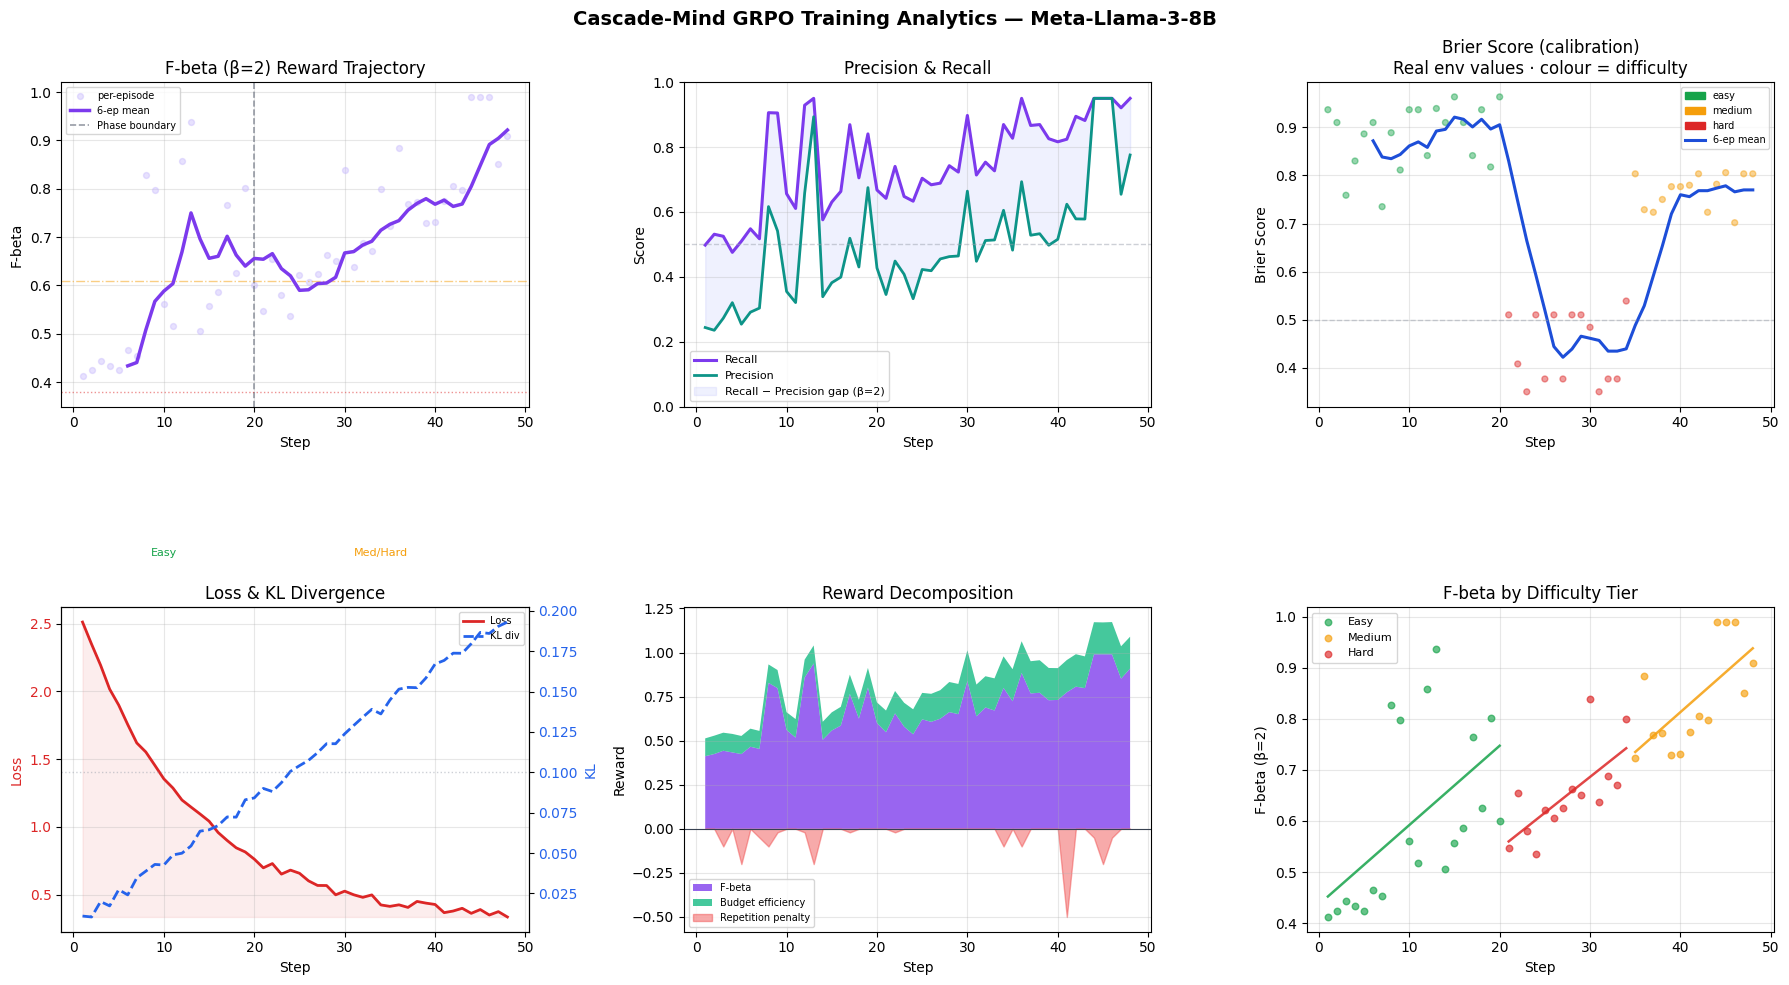

Saved: reward_curve.png  grpo_learning_curves_8b.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Memory stats ──────────────────────────────────────────────────────
if torch.cuda.is_available():
    used_gb      = torch.cuda.max_memory_reserved() / 1024**3
    training_gb  = used_gb - start_reserved_gb
    print(f"Training runtime : {trainer_stats.metrics['train_runtime']:.1f}s  "
          f"({trainer_stats.metrics['train_runtime']/60:.1f} min)")
    print(f"Peak VRAM        : {used_gb:.2f} GB / {max_memory_gb:.2f} GB "
          f"({used_gb/max_memory_gb*100:.1f}%)")
    print(f"Training overhead: {training_gb:.2f} GB")

# ── Extract logged metrics ────────────────────────────────────────────
log_history = trainer.state.log_history
steps      = [e["step"]                       for e in log_history if "reward_fbeta" in e]
fbetas     = [e["reward_fbeta"]               for e in log_history if "reward_fbeta" in e]
budgets    = [e.get("reward_budget", 0)       for e in log_history if "reward_fbeta" in e]
losses     = [e.get("loss", 0.0)              for e in log_history if "reward_fbeta" in e]
kls        = [e.get("kl", 0.0)               for e in log_history if "reward_fbeta" in e]
precisions = [e.get("precision", 0.0)         for e in log_history if "reward_fbeta" in e]
recalls    = [e.get("recall", 0.0)            for e in log_history if "reward_fbeta" in e]
briers     = [e.get("brier", 0.0)            for e in log_history if "reward_fbeta" in e]
rep_rews   = [e.get("repetition_reward", 0.0) for e in log_history if "reward_fbeta" in e]
diffs      = [e.get("difficulty", "easy")     for e in log_history if "reward_fbeta" in e]

print(f"Logged {len(steps)} training steps")
if fbetas:
    print(f"F-beta  : {min(fbetas):.3f} → {max(fbetas):.3f}  (final 5-step mean={np.mean(fbetas[-5:]):.3f})")
if briers:
    print(f"Brier   : {min(briers):.3f} → {max(briers):.3f}  (mean={np.mean(briers):.3f})")

_win      = max(3, len(steps) // 8)
_rm       = np.convolve(fbetas, np.ones(_win)/_win, mode="valid") if len(fbetas) >= _win else np.array(fbetas)
_steps_rm = steps[_win-1:] if len(steps) >= _win else steps
_b_rm     = np.convolve(briers, np.ones(_win)/_win, mode="valid") if len(briers) >= _win else np.array(briers)

_dc  = {"easy": "#16a34a", "medium": "#f59e0b", "hard": "#dc2626"}
_phase_split = sum(1 for d in diffs if d == "easy")

# ═══════════════════════════════════════════════════════════════════════
# 2 × 3 Research Dashboard — 6 panels
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Cascade-Mind GRPO Training Analytics — Meta-Llama-3-8B",
             fontsize=14, fontweight="bold")

# ── (0,0)  F-beta trajectory ──────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(steps, fbetas, color="#c4b5fd", s=18, alpha=0.4, zorder=2, label="per-episode")
ax.plot(_steps_rm, _rm, color="#7c3aed", lw=2.5, zorder=3, label=f"{_win}-ep mean")
ax.axvline(_phase_split, color="#6b7280", ls="--", lw=1.2, alpha=0.7, label="Phase boundary")
ax.axhline(0.61, color="#f59e0b", ls="-.", lw=1, alpha=0.5)
ax.axhline(0.38, color="#dc2626", ls=":",  lw=1, alpha=0.5)
ax.text(_phase_split/2, 0.04, "Easy", ha="center", fontsize=8, color="#16a34a")
ax.text(_phase_split + (len(steps)-_phase_split)/2, 0.04, "Med/Hard", ha="center", fontsize=8, color="#f59e0b")
ax.set_title("F-beta (β=2) Reward Trajectory"); ax.set_xlabel("Step"); ax.set_ylabel("F-beta")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── (0,1)  Precision vs Recall over training ─────────────────────────
ax = axes[0, 1]
ax.plot(steps, recalls,    color="#7c3aed", lw=2.2, label="Recall")
ax.plot(steps, precisions, color="#0d9488", lw=2.0, label="Precision")
ax.fill_between(steps, precisions, recalls, alpha=0.12, color="#818cf8",
                label="Recall − Precision gap (β=2)")
ax.axhline(0.5, color="#9ca3af", ls="--", lw=1, alpha=0.5)
ax.set_title("Precision & Recall"); ax.set_xlabel("Step"); ax.set_ylabel("Score")
ax.set_ylim(0, 1.0); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── (0,2)  Brier score trajectory (REAL values from env) ─────────────
ax = axes[0, 2]
_bcols = [_dc[d] for d in diffs]
ax.scatter(steps, briers, c=_bcols, s=18, alpha=0.45, zorder=2)
ax.plot(_steps_rm, _b_rm, color="#1d4ed8", lw=2.2, label=f"{_win}-ep mean")
ax.axhline(0.5, color="#9ca3af", ls="--", lw=1, alpha=0.5)
ax.set_title("Brier Score (calibration)\nReal env values · colour = difficulty")
ax.set_xlabel("Step"); ax.set_ylabel("Brier Score")
ax.grid(alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color=_dc["easy"],   label="easy"),
    mpatches.Patch(color=_dc["medium"], label="medium"),
    mpatches.Patch(color=_dc["hard"],   label="hard"),
] + ax.get_legend_handles_labels()[0], fontsize=7)

# ── (1,0)  Loss & KL divergence (dual axis) ──────────────────────────
ax  = axes[1, 0]
ax2 = ax.twinx()
ax.plot(steps, losses, color="#dc2626", lw=2.0, label="Loss")
ax.fill_between(steps, losses, min(losses), color="#dc2626", alpha=0.08)
ax2.plot(steps, kls, color="#2563eb", lw=2.0, ls="--", label="KL div")
ax2.axhline(0.1, color="#9ca3af", ls=":", lw=1, alpha=0.5)
ax.set_ylabel("Loss", color="#dc2626"); ax2.set_ylabel("KL", color="#2563eb")
ax.tick_params(axis="y", labelcolor="#dc2626"); ax2.tick_params(axis="y", labelcolor="#2563eb")
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=7); ax.set_title("Loss & KL Divergence")
ax.set_xlabel("Step"); ax.grid(alpha=0.3)

# ── (1,1)  Reward decomposition ──────────────────────────────────────
ax = axes[1, 1]
ax.stackplot(steps, fbetas, budgets,
             labels=["F-beta", "Budget efficiency"],
             colors=["#7c3aed", "#10b981"], alpha=0.78)
ax.fill_between(steps, [-abs(r) for r in rep_rews], 0,
                color="#ef4444", alpha=0.45, label="Repetition penalty")
ax.axhline(0, color="#374151", lw=0.8)
ax.set_title("Reward Decomposition"); ax.set_xlabel("Step"); ax.set_ylabel("Reward")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── (1,2)  F-beta by difficulty tier ─────────────────────────────────
ax = axes[1, 2]
for d, col in _dc.items():
    idxs = [i for i, diff in enumerate(diffs) if diff == d]
    _sx  = [steps[i]  for i in idxs]
    _fy  = [fbetas[i] for i in idxs]
    ax.scatter(_sx, _fy, color=col, s=22, alpha=0.65, label=d.capitalize(), zorder=2)
    if len(_sx) >= 3:
        _xs = np.linspace(min(_sx), max(_sx), 60)
        ax.plot(_xs, np.poly1d(np.polyfit(_sx, _fy, 1))(_xs),
                color=col, lw=1.8, alpha=0.85)
ax.set_title("F-beta by Difficulty Tier"); ax.set_xlabel("Step"); ax.set_ylabel("F-beta (β=2)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/reward_curve.png",            dpi=150, bbox_inches="tight")
plt.savefig("/content/grpo_learning_curves_8b.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reward_curve.png  grpo_learning_curves_8b.png")


## 14 — Save & Push to Hub

In [15]:
trainer.save_model(OUTPUT_DIR)
print(f"✅ Model saved locally to ./{OUTPUT_DIR}")

# Uncomment to push to Hub:
# grpo_config.push_to_hub = True
# trainer.push_to_hub()
# print(f"✅ Pushed to https://huggingface.co/<your-username>/{OUTPUT_DIR}")

✅ Model saved locally to ./cascade-mind-grpo-llama3-8B
